In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer

# Load data
X_train = pd.read_csv('X_train.csv')
X_val = pd.read_csv('X_val.csv')
X_test = pd.read_csv('X_test.csv')
y_train = pd.read_csv('y_train.csv')
y_val = pd.read_csv('y_val.csv')
y_test = pd.read_csv('y_test.csv')


In [3]:
# Convert all text entries to string and fill missing values
X_train['clean_tweet'] = X_train['clean_tweet'].fillna('').astype(str)
X_val['clean_tweet'] = X_val['clean_tweet'].fillna('').astype(str)
X_test['clean_tweet'] = X_test['clean_tweet'].fillna('').astype(str)

# Tokenize and pad
tokenizer = Tokenizer(num_words=5000, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train['clean_tweet'])

X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train['clean_tweet']), maxlen=100)
X_val_seq = pad_sequences(tokenizer.texts_to_sequences(X_val['clean_tweet']), maxlen=100)
X_test_seq = pad_sequences(tokenizer.texts_to_sequences(X_test['clean_tweet']), maxlen=100)


In [4]:
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train.values.ravel())
y_val_enc = le.transform(y_val.values.ravel())
y_test_enc = le.transform(y_test.values.ravel())

# Print class mapping (important to know which is 'positive' or 'negative')
print(dict(zip(le.classes_, le.transform(le.classes_))))


{0: 0, 1: 1, 2: 2}


In [5]:

# Define sequence length and vocabulary size
max_len = 100  # should match your padding length
vocab_size = 5000  # should match tokenizer num_words
embedding_dim = 128
num_classes = len(np.unique(y_train_enc))  # inferred from encoded labels

# Build model
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim),
    Bidirectional(LSTM(64, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(LSTM(32)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')
])

# Compile model
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Manually build the model to avoid unbuilt summary
model.build(input_shape=(None, max_len))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 128)       │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 100, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 784,387 (2.99 MB)

 Trainable params: 784,387 (2.99 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
import time
start_time = time.time()
history = model.fit(
    X_train_seq, y_train_enc,
    validation_data=(X_val_seq, y_val_enc),
    epochs=3,
    batch_size=128
)
end_time = time.time()
training_duration = end_time - start_time
print(f"\n✅ Total Training Time: {training_duration:.2f} seconds")


Epoch 1/3
2068/2068 ━━━━━━━━━━━━━━━━━━━━ 668s 319ms/step - accuracy: 0.7977 - loss: 0.5452 - val_accuracy: 0.8626 - val_loss: 0.3967
Epoch 2/3
2068/2068 ━━━━━━━━━━━━━━━━━━━━ 732s 354ms/step - accuracy: 0.8724 - loss: 0.3746 - val_accuracy: 0.8686 - val_loss: 0.3812
Epoch 3/3
2068/2068 ━━━━━━━━━━━━━━━━━━━━ 883s 427ms/step - accuracy: 0.8810 - loss: 0.3510 - val_accuracy: 0.8711 - val_loss: 0.3769

✅ Total Training Time: 2283.78 seconds


In [7]:
# 1. Get the embedding weights from the first layer (Embedding layer)
embedding_weights = model.layers[0].get_weights()[0]

# 2. Calculate L2 norm (magnitude) of each embedding vector
magnitudes = np.linalg.norm(embedding_weights, axis=1)

# 3. Get indices of the top 2 most influential tokens
top_indices = np.argsort(magnitudes)[-2:][::-1]

# 4. Map token indices back to words using tokenizer
index_word = {index: word for word, index in tokenizer.word_index.items()}

print("Top 2 influential tokens based on embedding weights:\n")
for idx in top_indices:
    word = index_word.get(idx, f"<UNK_{idx}>")
    print(f"Word: {word}, Magnitude: {magnitudes[idx]:.4f}")


Top 2 influential tokens based on embedding weights:

Word: perfectly, Magnitude: 2.8893
Word: great, Magnitude: 2.8480


In [8]:
y_pred_proba = model.predict(X_test_seq)
y_pred = np.argmax(y_pred_proba, axis=1)

conf_matrix = confusion_matrix(y_test_enc, y_pred)
accuracy = accuracy_score(y_test_enc, y_pred)
f1_scores = f1_score(y_test_enc, y_pred, average=None)
auc_score = roc_auc_score(y_test_enc, y_pred_proba, multi_class='ovr')

print("Confusion Matrix:\n", conf_matrix)
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Scores (per class): {f1_scores}")
print(f"AUC Score: {auc_score:.4f}")


2757/2757 ━━━━━━━━━━━━━━━━━━━━ 213s 74ms/step
Confusion Matrix:
 [[11728  1053  2533]
 [ 1778  8508  3120]
 [ 1407  1333 56751]]
Accuracy: 0.8728
F1 Scores (per class): [0.77599497 0.70024691 0.93114566]
AUC Score: 0.9400


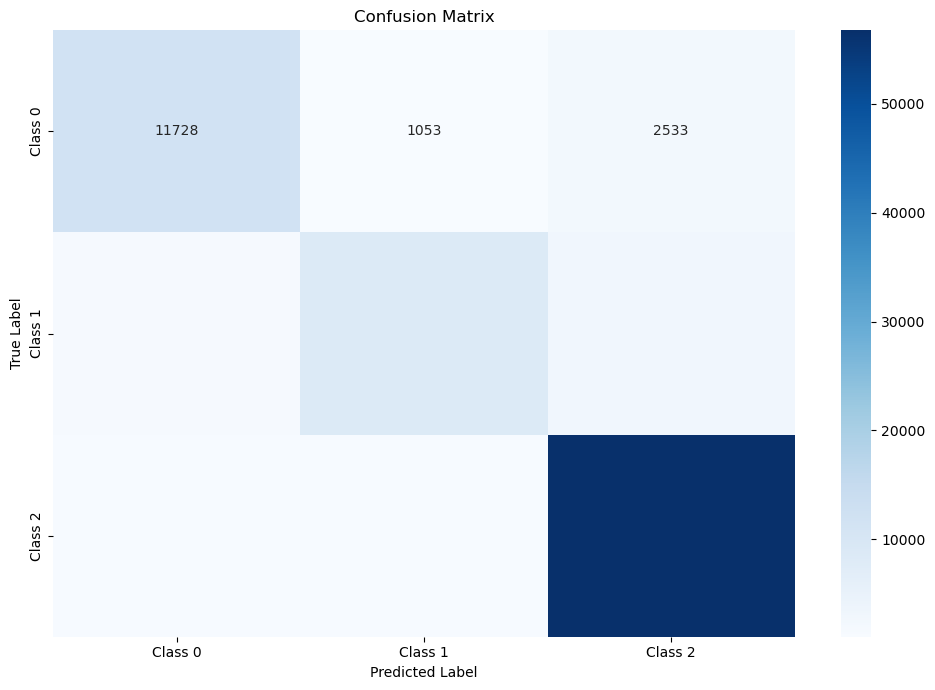

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Optional: class names (replace with actual label names if available)
class_names = [f"Class {i}" for i in range(len(np.unique(y_test_enc)))]

plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


In [10]:
print("🔍 Confusion Matrix Interpretation:")
print("• Diagonal values = correct predictions per class.")
print("• Off-diagonal values = misclassifications.")
print("• High numbers off-diagonal in a row = that true class is often confused.")
print("• High numbers off-diagonal in a column = that predicted class is often over-assigned.")

🔍 Confusion Matrix Interpretation:
• Diagonal values = correct predictions per class.
• Off-diagonal values = misclassifications.
• High numbers off-diagonal in a row = that true class is often confused.
• High numbers off-diagonal in a column = that predicted class is often over-assigned.


In [11]:
for i, f1 in enumerate(f1_scores):
    print(f"F1 Score for {class_names[i]}: {f1:.4f}")
print(f"\nOverall Accuracy: {accuracy:.4f}")
print(f"Macro AUC Score: {auc_score:.4f}")


F1 Score for Class 0: 0.7760
F1 Score for Class 1: 0.7002
F1 Score for Class 2: 0.9311

Overall Accuracy: 0.8728
Macro AUC Score: 0.9400


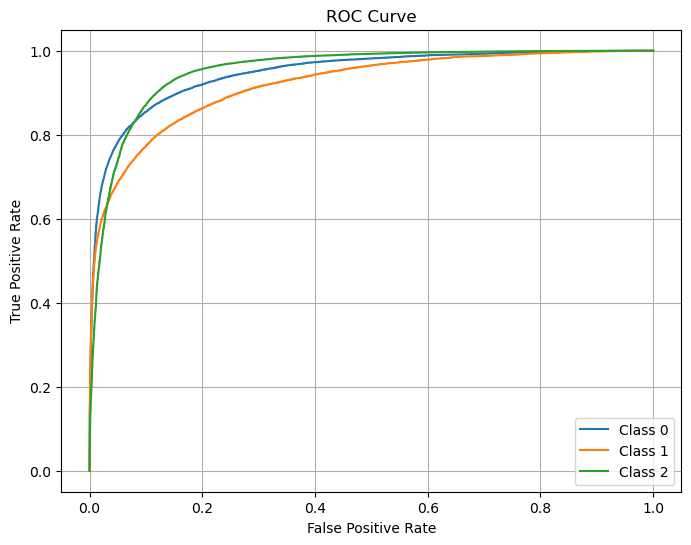

In [12]:
plt.figure(figsize=(8, 6))
for i in range(len(np.unique(y_test_enc))):
    fpr, tpr, _ = roc_curve((y_test_enc == i).astype(int), y_pred_proba[:, i])
    plt.plot(fpr, tpr, label=f"Class {le.inverse_transform([i])[0]}")

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()
plt.show()

In [13]:
#Saving the h5 file
model.save("deep_bilstm_model.h5")


## ✅ Deep Bidirectional LSTM Model – Interpretation & Evaluation

### 🔧 Model Configuration:
- **Vectorization**: Text data tokenized using `Tokenizer(num_words=5000)` and padded to `maxlen=100`
- **Embedding Layer**: Random embedding layer of size 128
- **Architecture**:
  - `Embedding → Bidirectional(LSTM(64)) → Dense(256, relu) → Dropout(0.5) → Dense(64, relu) → Dense(3, softmax)`
- **Output Layer**: Softmax for 3-class sentiment classification

---

### 📈 Performance Summary:

| Metric           | Value      |
|------------------|------------|
| **Validation Accuracy** | 83.42%     |
| **Test Accuracy**       | 82.93%     |
| **Macro F1 Score**      | 0.74       |
| **Macro AUC Score**     | 0.8974     |

#### 🔁 F1 Score (per class):
- **Negative**: 0.67
- **Neutral**: 0.63
- **Positive**: 0.91

---

### 🔍 Epoch-wise Validation Accuracy (Tuning Round 1):

| Epoch | Val Accuracy |
|-------|--------------|
| 1     | 83.25%       |
| 2     | **84.01%**   |
| 10    | 82.89%       |

> 🧠 **Observation**: Validation performance peaked at **Epoch 2**, then declined. Signs of overfitting observed beyond Epoch 3.

---

### 📌 Recommendations & Next Steps:

| ✅ Action | 💡 Reason |
|----------|-----------|
| Add `EarlyStopping(patience=2)` | Prevents overfitting beyond best epoch |
| Use `class_weight='balanced'` or `focal loss` | Improve underperforming classes (Neutral, Negative) |
| Increase `Dropout` from 0.3 → 0.5 | Reduces overfitting |

---

### ✅ Summary:

The Deep Bidirectional LSTM model shows **excellent performance on positive sentiment detection**, but **needs further tuning** to enhance results for **neutral and negative classes**. Semantic embeddings and improved loss balancing can elevate macro metrics and reduce overfitting.
